In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

# Atlas and data from the age prediction practical
repository_path = Path("..")
atlas = pd.read_table(repository_path / "atlas-Schaefer2018Combined_dseg.tsv")
atlas.head()

,index,name,network,color
0,1,Schaefer2018_17Networks_LH_VisCent_ExStr_1,Vis,#781286
1,2,Schaefer2018_17Networks_LH_VisCent_ExStr_2,Vis,#781286
2,3,Schaefer2018_17Networks_LH_VisCent_ExStr_3,Vis,#781286
3,4,Schaefer2018_17Networks_LH_VisCent_ExStr_4,Vis,#781286
4,5,Schaefer2018_17Networks_LH_VisCent_ExStr_5,Vis,#781286


In [3]:
from urllib.request import urlretrieve

import nibabel as nib
from nilearn import datasets

# Schaefer parcellation of the left hemisphere on the fsaverage6 surface
annotation_url = (
    "https://raw.githubusercontent.com/ThomasYeoLab/CBIG/master/stable_projects/brain_parcellation/"
    "Schaefer2018_LocalGlobal/Parcellations/FreeSurfer5.3/fsaverage6/label/"
    "lh.Schaefer2018_400Parcels_17Networks_order.annot"
)
annotation_path = Path("lh.Schaefer2018_400Parcels_17Networks_order.annot")
if not annotation_path.is_file():
    urlretrieve(annotation_url, annotation_path)
parcels, _, _ = nib.freesurfer.read_annot(annotation_path)  # 0 is the medial wall

fsaverage_meshes = datasets.load_fsaverage("fsaverage6")
fsaverage_sulcal = datasets.load_fsaverage_data(mesh="fsaverage6", data_type="sulcal", mesh_type="inflated")

[load_fsaverage] Dataset found in /lea/nilearn_data/fsaverage6
[load_fsaverage_data] Dataset found in /lea/nilearn_data/fsaverage6
[load_fsaverage_data] Dataset found in /lea/nilearn_data/fsaverage6


In [4]:
from matplotlib.colors import ListedColormap, to_rgb

# Color each parcel by its network, as in the time series and connectivity plots,
# with a slightly different shade per parcel so that the parcels are visible
rng = np.random.default_rng(0)
parcel_colors = []
for color in atlas.set_index("index").color.loc[1:200]:
    shade = rng.uniform(-0.25, 0.25)
    rgb = np.array(to_rgb(color))
    parcel_colors.append(rgb + shade * (1 - rgb) if shade > 0 else rgb * (1 + shade))
network_cmap = ListedColormap(["#dddddd", *parcel_colors])

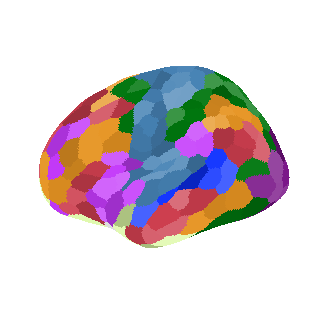

In [5]:
from matplotlib import pyplot as plt
from nilearn import plotting
from PIL import Image, ImageChops

figure, axes = plt.subplots(figsize=(4, 3), subplot_kw=dict(projection="3d"))
plotting.plot_surf_roi(
    surf_mesh=fsaverage_meshes["inflated"].parts["left"],
    roi_map=parcels,
    bg_map=fsaverage_sulcal.data.parts["left"],
    hemi="left",
    view="lateral",
    cmap=network_cmap,
    vmin=0,
    vmax=200,
    colorbar=False,
    axes=axes,
    figure=figure,
)
figure.subplots_adjust(left=0, right=1, bottom=0, top=1)
figure.savefig("schaefer-atlas.png", dpi=300)

# Crop the white margin around the brain
with Image.open("schaefer-atlas.png") as png:
    png = png.convert("RGB")
    png.crop(ImageChops.invert(png).getbbox()).save("schaefer-atlas.png")

In [6]:
import scipy.stats

# Sort the regions so that regions of the same network are next to each other
atlas["network"] = pd.Categorical(atlas.network, categories=atlas.network.unique())
atlas = atlas.sort_values("network", kind="stable")
atlas["position"] = np.arange(len(atlas))

time_series_path = repository_path / "ds000030-halfpipe/sub-10159/func/sub-10159_task-rest_timeseries.tsv"
values = np.nan_to_num(np.loadtxt(time_series_path, delimiter="\t"))

# Denoise as in the practical, by regressing out motion, white matter, CSF and global signal
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

confounds_columns = [
    *(f"{param}_{axis}" for param in ["trans", "rot"] for axis in ["x", "y", "z"]),
    "white_matter",
    "csf",
    "global_signal",
]
confounds = pd.read_table(time_series_path.parent / time_series_path.name.replace("timeseries", "desc-confounds_timeseries"))
confounds = confounds[confounds_columns].to_numpy()
model = make_pipeline(SimpleImputer(strategy="constant"), StandardScaler(), LinearRegression())
values = values - model.fit(confounds, values).predict(confounds)

values = values[:, atlas.index]
repetition_time = 2  # Seconds between two volumes

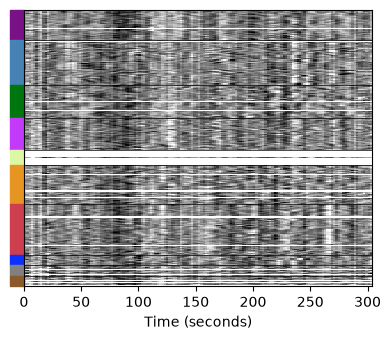

In [7]:
from matplotlib.patches import Rectangle


def add_network_bars(axes, axis="y"):
    """Draw a colored bar for each network on the left or bottom of the plot"""
    for network, regions in atlas.groupby("network", observed=True):
        start = regions.position.min() - 0.5
        end = regions.position.max() + 0.5
        if axis == "y":
            bar = Rectangle(
                (-0.04, start),
                width=0.04,
                height=end - start,
                color=regions.color.iloc[0],
                transform=axes.get_yaxis_transform(),
                clip_on=False,
            )
            axes.axhline(end, color="black", linewidth=0.5)  # Line between networks
        else:
            bar = Rectangle(
                (start, -0.04),
                width=end - start,
                height=0.04,
                color=regions.color.iloc[0],
                transform=axes.get_xaxis_transform(),
                clip_on=False,
            )
            axes.axvline(end, color="black", linewidth=0.5)  # Line between networks
        axes.add_patch(bar)
    if axis == "y":
        axes.set_yticks([])
    else:
        axes.set_xticks([])


z_scores = scipy.stats.zscore(values, axis=0, nan_policy="omit")
duration = len(z_scores) * repetition_time

figure, axes = plt.subplots(figsize=(4, 3.5))
axes.imshow(
    z_scores.transpose(),
    cmap="gray",
    vmin=-3,
    vmax=3,
    aspect="auto",
    interpolation="nearest",
    extent=(0, duration, len(atlas) - 0.5, -0.5),
)
axes.set_xlabel("Time (seconds)")
add_network_bars(axes)
figure.tight_layout()
figure.savefig("time-series.png", dpi=300)

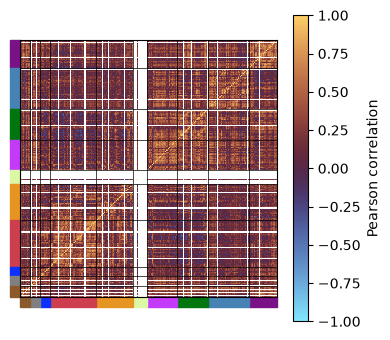

In [14]:
matrix = pd.DataFrame(values).corr().to_numpy()

figure, axes = plt.subplots(figsize=(4, 3.5))
image = axes.imshow(matrix, cmap="managua_r", vmin=-1, vmax=1, interpolation="nearest")
figure.colorbar(image, label="Pearson correlation", ax=axes)
add_network_bars(axes, axis="y")
add_network_bars(axes, axis="x")
axes.set_yinverted(True)
axes.set_xinverted(True)
figure.tight_layout()
figure.savefig("connectivity-matrix.png", dpi=300)